<a href="https://colab.research.google.com/github/Shaunak-Mukherjee/ECE-59500---Reinforcement-Learning--Theory-and-Algorithms/blob/main/ECE_59500_Reinforcement_Learning_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

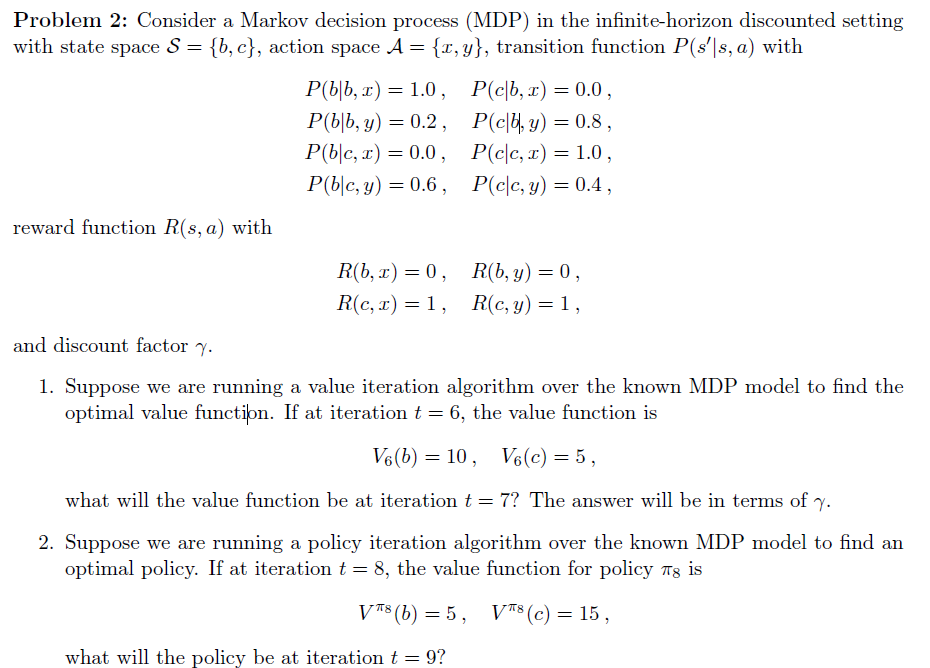

Answer to P2.1

In [20]:
# ---- MDP ----
states = ["b", "c"] # State space
actions = ["x", "y"] # Action space

# Transition probabilities
P = {
    ("b","x"): {"b":1.0, "c":0.0},
    ("b","y"): {"b":0.2, "c":0.8},
    ("c","x"): {"b":0.0, "c":1.0},
    ("c","y"): {"b":0.6, "c":0.4},
}

# Rewards
R = {
    ("b","x"): 0.0, ("b","y"): 0.0,
    ("c","x"): 1.0, ("c","y"): 1.0,
}
# Discount
gamma = .95 # I assumed

In [21]:
# Answert Par1
# V6 is given
V_6 = {"b": 10.0, "c": 5.0}
# V7 can be evaluated from V_next
V_next = {}

for s in states:
  best = float("-inf")
  for a in actions:
    exp_next = 0.0
    for sp in states:
      exp_next += P[(s,a)][sp] * V_6[sp]
    q = R[(s,a)] + gamma * exp_next
    # print(q)
    if q > best:
        best = q
V_next[s] = best

print("V7:", V_next)  # {'b': 10*gamma, 'c': 1 + 8*gamma}


V7: {'c': 8.6}


P2.1 Answer: Value function at $t = 7: V_7(b) = 10$$\gamma$	, V_7(c) = 1+8$\gamma$

Answer to P2.2

In [22]:
# Answer Part2:
V_pi8 = {"b": 5.0, "c": 15.0}  # given

pi9 = {} # unknown
for s in states:
  best_a = None
  best_q = float("-inf")
  for a in actions:
    # q(s,a) = R(s,a)+gamma*sum_{s'} P(s'|s,a)*V^{pi8}(s')
    exp_next = 0.0
    for sp in states:
      exp_next += P[(s, a)][sp] * V_pi8[sp]
    q = R[(s, a)] + gamma * exp_next
    if q > best_q:
        best_q, best_a = q, a
  pi9[s] = best_a
print("pi9:", pi9)  # results

pi9: {'b': 'y', 'c': 'x'}


P2.2 The improved policy at $t=9$ is $\pi_9(b)=y$ and $\pi_9(c)=x$.


<br>

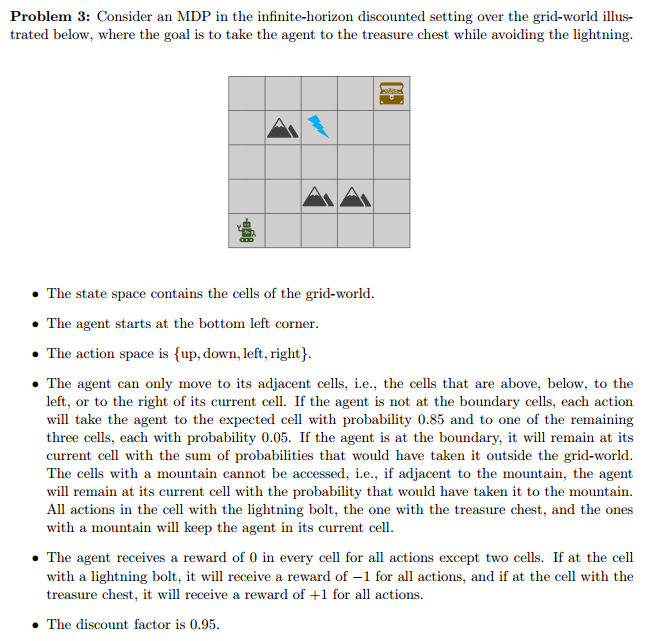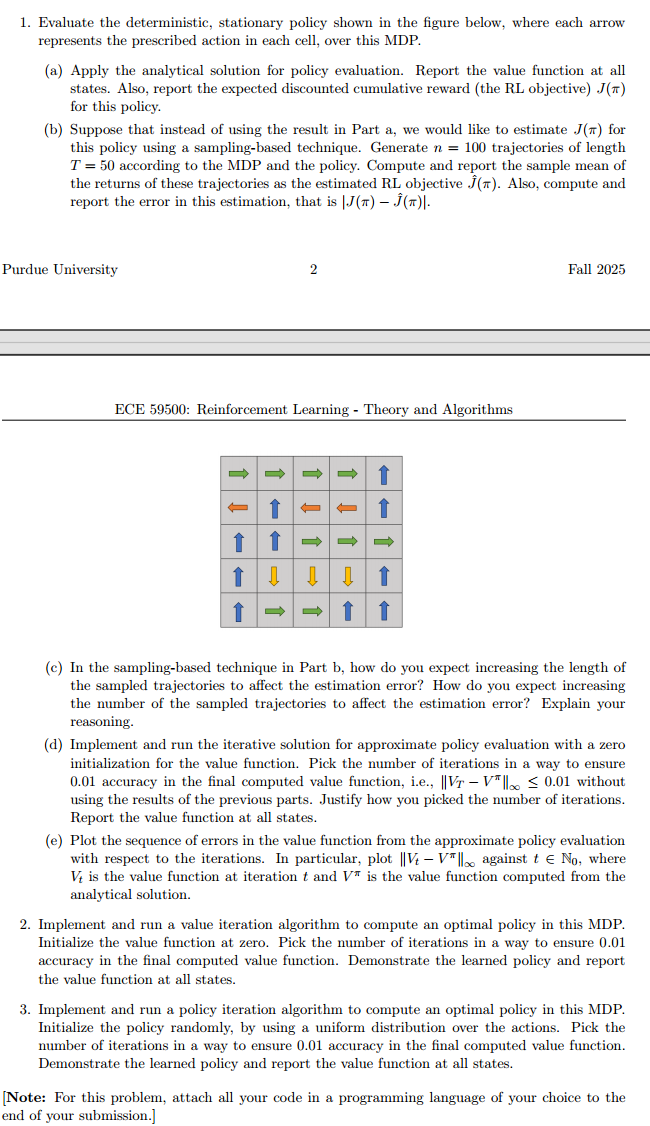

Answer3.1(a): Analytic policy evaluation
	​


In [23]:
"""
Gridworld policy evaluation

MDP:
- 5x5 grid (x=0 to 4 left→right, y=0 to 4 bottom→top), agent start at (0,0)
- Actions: U,D,L,R. Intended = 0.85, each other = 0.05
- Mountains, Lightning, Treasure are absorbing
- Rewards: -1 on Lightning, +1 on Treasure, 0 elsewhere
- Discount gamma = 0.95

Outputs:
- Value function V_pi (per-state and as a 5x5 grid)
- J(pi) = V_pi(start)
"""

import numpy as np
from typing import Dict, Tuple, List

# Problem spec
W, H = 5, 5
GAMMA = 0.95

# Cell types
N, M, L, T = "N", "M", "L", "T"  # normal, mountain, lightning, treasure

# Board layout (x,y) with (0,0) bottom-left
MOUNTAINS = {(2, 1), (3, 1), (1, 3)}
LIGHTNING = (2, 3)
TREASURE  = (4, 4)

# Policy
policy_cols = [
    "URRUU",
    "UDDDU",
    "UURRR",
    "LULLU",
    "RRRRU",
]
policy_grid = np.array([list(col) for col in policy_cols]).T  # shape (5,5), index with [x,y]

# Actions
ACTIONS: Dict[str, Tuple[int, int]] = {
    "U": (0, 1),
    "D": (0,-1),
    "L": (-1,0),
    "R": (1, 0),
}

DIRECTIONS = ["U","D","L","R"]
P_INTENDED, P_OTHER = 0.85, 0.05

START = (0, 0)  # bottom-left

# Helper funcs
def s_idx(x: int, y: int) -> int:
  """(x,y) -> state index"""
  return y * W + x

def inv_idx(s: int) -> Tuple[int, int]:
  """state index -> (x,y)."""
  return (s % W, s // W)

def in_bounds(x: int, y: int) -> bool:
  return 0 <= x < W and 0 <= y < H

def build_board() -> np.ndarray:
  board = np.full((W, H), N, dtype="<U1")
  for (x, y) in MOUNTAINS:
      board[x, y] = M
  board[LIGHTNING] = L
  board[TREASURE]  = T
  return board

# ---------- Core: build P_pi and r_pi ----------
def build_mdp_matrices(policy: np.ndarray, gamma: float = GAMMA):
  board = build_board()
  absorbing = set(MOUNTAINS) | {LIGHTNING, TREASURE}
  nS = W * H

  P = np.zeros((nS, nS), dtype=float)  # transition matrix under the policy
  r = np.zeros(nS, dtype=float)        # reward vector under the policy

  for x in range(W):
    for y in range(H):
        s = s_idx(x, y)

        # Rewards by state
        if (x, y) == LIGHTNING:
            r[s] = -1.0
        elif (x, y) == TREASURE:
            r[s] = 1.0
        else:
            r[s] = 0.0

        #  Mountain, lightning, treasure
        if (x, y) in absorbing:
            P[s, s] = 1.0
            continue

        a = policy[x, y]
        if a not in ACTIONS:  # defensive fallback
            P[s, s] = 1.0
            continue

        probs = {d: P_OTHER for d in DIRECTIONS}
        probs[a] = P_INTENDED

        # Distribute probability mass
        for d, p in probs.items():
            dx, dy = ACTIONS[d]
            nx, ny = x + dx, y + dy
            if not in_bounds(nx, ny) or board[nx, ny] == M:
                P[s, s] += p
            else:
                P[s, s_idx(nx, ny)] += p

  return P, r, board

# Print funcs
def print_transitions(P: np.ndarray):
  print("Non-zero transitions under policy (P_pi)")
  nS = P.shape[0]
  for s in range(nS):
      row = P[s]
      nz = np.where(row > 1e-12)[0]
      parts = [f"{s:2d} → {sp:2d}: {row[sp]:.4f}" for sp in nz]
      print(", ".join(parts))
      print()

def print_rewards(r: np.ndarray):
  print("Reward vector r_pi")
  for s, rv in enumerate(r):
      print(f"s={s:2d}: {rv:+.1f}")
  print()

def print_values(v: np.ndarray):
  print("Value function V_pi (per state)")
  for s, vv in enumerate(v):
      print(f"s={s:2d}: {vv: .10f}")
  print("\n V_pi as 5x5 grid (y=top→bottom rows)")
  grid = np.zeros((H, W))
  for s, vv in enumerate(v):
    x, y = inv_idx(s)
    grid[H - 1 - y, x] = vv
  output_lines = []
  for row in grid:
    formatted_row = [f'{x:10.3f}' for x in row]
    output_lines.append(f"[{' '.join(formatted_row)}]")

  print('\n'.join(output_lines))

# Main
def main():
  P, r, board = build_mdp_matrices(policy_grid, GAMMA)
  I = np.eye(P.shape[0])
  A = I - GAMMA * P
  v = np.linalg.solve(A, r)
  # print_transitions(P)
  # print_rewards(r)
  print_values(v)

  start_s = s_idx(*START)
  J = v[start_s]
  print(f"RL objective \nJ(pi) = V_pi(start @ {START}, s={start_s}) = {J:.10f}")

if __name__ == "__main__":
    main()

Value function V_pi (per state)
s= 0:  4.3389642925
s= 1:  2.6412756361
s= 2:  2.7064370567
s= 3:  2.8778513233
s= 4:  6.0785827724
s= 5:  4.7074948508
s= 6:  2.6161329734
s= 7:  0.0000000000
s= 8:  0.0000000000
s= 9:  6.6432439272
s=10:  5.1436801551
s=11:  2.8511700123
s=12:  3.7949285003
s=13:  5.4851254748
s=14:  7.0878056624
s=15:  5.6226857792
s=16:  0.0000000000
s=17: -20.0000000000
s=18: -14.2964244507
s=19:  16.5958956510
s=20:  12.0203080131
s=21:  13.1409302505
s=22:  14.0205290973
s=23:  16.9416220165
s=24:  20.0000000000

 V_pi as 5x5 grid (y=top→bottom rows)
[    12.020     13.141     14.021     16.942     20.000]
[     5.623      0.000    -20.000    -14.296     16.596]
[     5.144      2.851      3.795      5.485      7.088]
[     4.707      2.616      0.000      0.000      6.643]
[     4.339      2.641      2.706      2.878      6.079]
RL objective 
J(pi) = V_pi(start @ (0, 0), s=0) = 4.3389642925


1(b) Answer: sampling-based technique

In [24]:
# Monte Carlo estimate of J(pi)
n, T = 100, 50
seed = 7
rng = np.random.default_rng(seed)

board = build_board()
absorbing = set(MOUNTAINS) | {LIGHTNING, TREASURE}

returns = []
for _ in range(n):
  x, y = START
  G = 0.0
  disc = 1.0
  for _ in range(T):
    # Reward at current state
    r_t = -1.0 if (x, y) == LIGHTNING else (1.0 if (x, y) == TREASURE else 0.0)

    # Sample one-step dynamics under the policy
    if (x, y) in absorbing:
      nx, ny = x, y
    else:
      a = policy_grid[x, y]
      probs = {d: P_OTHER for d in DIRECTIONS}
      probs[a] = P_INTENDED
      dirs = np.array(DIRECTIONS)
      pvals = np.array([probs[d] for d in dirs])
      outcome = rng.choice(dirs, p=pvals)
      dx, dy = ACTIONS[outcome]
      nx, ny = x + dx, y + dy
      # invalid or mountain -> self-loop (stay)
      if not in_bounds(nx, ny) or (nx, ny) in MOUNTAINS:
          nx, ny = x, y

    # Accumulate discounted return and advance
    G += disc * r_t
    disc *= GAMMA
    x, y = nx, ny

  returns.append(G)

returns = np.array(returns, dtype=float)
J_hat = float(returns.mean())

# J_true via analytical eval from 1(a)
P, r_vec, _ = build_mdp_matrices(policy_grid, GAMMA)
v = np.linalg.solve(np.eye(W * H) - GAMMA * P, r_vec)
J_true = float(v[s_idx(*START)])
err = abs(J_true - J_hat)

print("Answer to Part 3(b): Monte Carlo estimate of J(pi)")
print(f"n={n}, T={T}, gamma={GAMMA}, seed={seed}")
print(f"J_true (from part a) = {J_true:.6f}")
print(f"J_hat  (MC mean) = {J_hat:.6f}")
print(f"|J - J_hat| = {err:.6f}")


Answer to Part 3(b): Monte Carlo estimate of J(pi)
n=100, T=50, gamma=0.95, seed=7
J_true (from part a) = 4.338964
J_hat  (MC mean) = 2.935459
|J - J_hat| = 1.403505


**1(c) Answer:**

Part (c):
**Effect of $T$ and $n$ on the estimation error $|J(\pi)-\hat J(\pi)|$**

We know, $
|J(\pi)-J_T|
= \left|\mathbb{E}\!\sum_{t=T}^{\infty}\gamma^t r_t\right|
\le
\sum_{t=T}^{\infty}\gamma^t R_{\max}
=
\frac{R_{\max}\,\gamma^{T}}{1-\gamma}.
$

Thus, larger $T$ reduces the truncation contribution to the error in $T$.
Total error drops, then plateaus.


**Increasing number of trajectories $n$ on the estimation error $|J(\pi)-\hat J(\pi)|$.**

From earlier problem $G_i =\sum_{t=0}^{T-1}\gamma^t r_t^{(i)}$ be i.i.d. $T$-step returns with variance
$\sigma_T^2 = \mathrm{var}(G_i)$. The Monte Carlo estimator is
$\hat J(\pi) = \frac{1}{n}\sum_{i=1}^n G_i$, whose variance satisfies
$
\mathrm{var}\!\bigl(\hat J(\pi)\bigr) = \frac{\sigma_T^2}{n}
->
\text{Std Err}\!\bigl(\hat J(\pi)\bigr) = \frac{\sigma_T}{\sqrt{n}}.
$
So, the larger $n$ reduces the sampling contribution to the error at the rate
$1/\sqrt{n}$. Reduced standard error.


Answer to 3(d)

In [25]:
# Part 3(d): Iterative policy evaluation
R_max = 1.0
eps = 0.01 # given
gamma = GAMMA
T_needed = int(np.ceil(np.log(eps * (1 - gamma) / R_max) / np.log(gamma)))
print(f"Using T = {T_needed} iterations (guarantees sup-norm error ≤ {eps}).")

# MDP under the fixed policy
P, r_vec, _ = build_mdp_matrices(policy_grid, GAMMA)

# Iterative evaluation from v_0 = 0: v_{k+1} = r + γ P v_k
v = np.zeros(W * H)
for _ in range(T_needed):
  v = r_vec + gamma * (P @ v)

# Report the value function
print_values(v)

# Verification:
v_t = np.linalg.solve(np.eye(W * H) - GAMMA * P, r_vec)
max_error = np.linalg.norm(v_t - v, ord=np.inf)
print(f"Verification: ||V_T - V^π||_inf = {max_error:.6e}")

Using T = 149 iterations (guarantees sup-norm error ≤ 0.01).
Value function V_pi (per state)
s= 0:  4.3314138192
s= 1:  2.6335824566
s= 2:  2.6987306232
s= 3:  2.8701417978
s= 4:  6.0708325957
s= 5:  4.6999519072
s= 6:  2.6084828479
s= 7:  0.0000000000
s= 8:  0.0000000000
s= 9:  6.6354909151
s=10:  5.1361432195
s=11:  2.8441057310
s=12:  3.7888980274
s=13:  5.4782365675
s=14:  7.0800521649
s=15:  5.6151207859
s=16:  0.0000000000
s=17: -19.9904093690
s=18: -14.2894788132
s=19:  16.5872720565
s=20:  12.0127060714
s=21:  13.1333261021
s=22:  14.0129248161
s=23:  16.9330062610
s=24:  19.9904093690

 V_pi as 5x5 grid (y=top→bottom rows)
[    12.013     13.133     14.013     16.933     19.990]
[     5.615      0.000    -19.990    -14.289     16.587]
[     5.136      2.844      3.789      5.478      7.080]
[     4.700      2.608      0.000      0.000      6.635]
[     4.331      2.634      2.699      2.870      6.071]
Verification: ||V_T - V^π||_inf = 9.590631e-03


**Explanation**
Based on the given $\varepsilon = 0.01$ and $\gamma = 0.95$, the number of iterations $T$ required to guarantee a sup-norm error of at most $\varepsilon$ is:
$
T \;\ge\; \frac{\log\!\big(1/(\varepsilon(1-\gamma))\big)}{\log(1/\gamma)} = \frac{\log\!\big(1/(0.01\cdot 0.05)\big)}{\log(1/0.95)}$ is approx 148.19

So, $T = 149$ iterations was chosen.

The verification step shows that the sup-norm error between the value function after 149 iterations and the true value function (computed analytically) is approximately $9.59 \times 10^{-3}$, which is indeed less than the desired $\varepsilon = 0.01$.

Answer to 3(e)

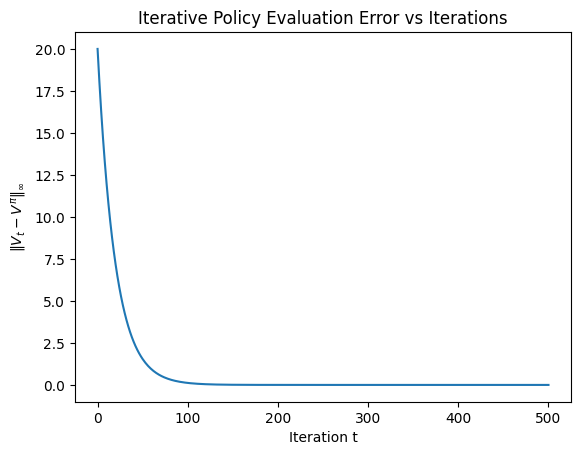

In [26]:
import matplotlib.pyplot as plt

# Exact V^pi from analytical solution
I = np.eye(W * H)
v_true = np.linalg.solve(I - GAMMA * P, r_vec)
T_iters = 500
v = np.zeros(W * H, dtype=float)
errors = [np.linalg.norm(v - v_true, ord=np.inf)]

for _ in range(T_iters):
  v = r_vec + GAMMA * (P @ v)
  errors.append(np.linalg.norm(v - v_true, ord=np.inf))

# Plot
plt.figure()
plt.plot(range(len(errors)), errors)
plt.xlabel("Iteration t")
plt.ylabel(r"$\|V_t - V^\pi\|_\infty$")
plt.title("Iterative Policy Evaluation Error vs Iterations")
plt.grid(False)
plt.show()

Answer to 3.2

In [27]:
# Iteration count from contraction bound
eps = 0.01
R_max = 1.0
gamma = GAMMA
T_needed = int(np.ceil(np.log(eps * (1 - gamma) / R_max) / np.log(gamma)))

# Rewards per state
nS = W * H
r_s = np.zeros(nS, dtype=float)
for s in range(nS):
    x, y = s % W, s // W
    r_s[s] = -1.0 if (x, y) == LIGHTNING else (1.0 if (x, y) == TREASURE else 0.0)

absorbing = set(MOUNTAINS) | {LIGHTNING, TREASURE}

#
def expected_next_value(x, y, a, v_vec):
  if (x, y) in absorbing:
      return v_vec[s_idx(x, y)]
  probs = {d: P_OTHER for d in DIRECTIONS}; probs[a] = P_INTENDED
  ssum = 0.0
  for d in DIRECTIONS:
      dx, dy = ACTIONS[d]
      nx, ny = x + dx, y + dy
      if not in_bounds(nx, ny) or (nx, ny) in MOUNTAINS:
          nx, ny = x, y
      ssum += probs[d] * v_vec[s_idx(nx, ny)]
  return ssum

# value iteration
v = np.zeros(nS)
for _ in range(T_needed):
  v_new = np.empty_like(v)
  for s in range(nS):
      x, y = s % W, s // W
      v_new[s] = max(r_s[s] + gamma * expected_next_value(x, y, a, v) for a in DIRECTIONS)
  v = v_new

# greedy policy
opt_policy = {}
for x in range(W):
  for y in range(H):
      if (x, y) in absorbing:
          opt_policy[(x, y)] = "*"
      else:
          opt_policy[(x, y)] = max(DIRECTIONS, key=lambda a: r_s[s_idx(x, y)] + gamma * expected_next_value(x, y, a, v))

# outputs
print(f"T_needed = {T_needed} (guarantees ||V_T - V*||_∞ ≤ {eps})")
print_values(v)
print("\nOptimal policy (top row first):")
for y in range(H - 1, -1, -1):
    print("".join(opt_policy[(x, y)] for x in range(W)))

T_needed = 149 (guarantees ||V_T - V*||_∞ ≤ 0.01)
Value function V_pi (per state)
s= 0:  11.8498918376
s= 1:  12.6139650108
s= 2:  13.4835636235
s= 3:  14.3702019273
s= 4:  15.3127428056
s= 5:  11.3441779814
s= 6:  11.8827371692
s= 7:  0.0000000000
s= 8:  0.0000000000
s= 9:  16.3169337370
s=10:  11.9857041402
s=11:  12.5084694920
s=12:  13.3510678156
s=13:  16.1891050958
s=14:  17.3869301473
s=15:  12.7353604407
s=16:  0.0000000000
s=17: -19.9904093690
s=18:  15.7151904704
s=19:  18.5975114130
s=20:  13.5685462059
s=21:  14.4582358964
s=22:  15.4063384908
s=23:  18.4987448202
s=24:  19.9904093690

 V_pi as 5x5 grid (y=top→bottom rows)
[    13.569     14.458     15.406     18.499     19.990]
[    12.735      0.000    -19.990     15.715     18.598]
[    11.986     12.508     13.351     16.189     17.387]
[    11.344     11.883      0.000      0.000     16.317]
[    11.850     12.614     13.484     14.370     15.313]

Optimal policy (top row first):
RRRR*
U**RU
URRRU
UD**U
RRRRU


Answer to 3.3



In [28]:
# 3.3: Policy Iteration
eps = 0.01
A_LETTERS = DIRECTIONS  # ["U","D","L","R"]
nA, nS = len(A_LETTERS), W * H

# Per-action transitions P_a
def build_P_for_action(a_letter):
  P_a = np.zeros((nS, nS), dtype=float)
  for x in range(W):
    for y in range(H):
        s = s_idx(x, y)
        if (x, y) in ({LIGHTNING, TREASURE} | set(MOUNTAINS)):
            P_a[s, s] = 1.0
            continue
        probs = {d: P_OTHER for d in DIRECTIONS}; probs[a_letter] = P_INTENDED
        for d, p in probs.items():
            dx, dy = ACTIONS[d]
            nx, ny = x + dx, y + dy
            if not in_bounds(nx, ny) or (nx, ny) in MOUNTAINS:
                P_a[s, s] += p
            else:
                P_a[s, s_idx(nx, ny)] += p
  return P_a

P_actions = {a: build_P_for_action(a) for a in A_LETTERS}

# State-only rewards
r_vec = np.zeros(nS, dtype=float)
for s in range(nS):
  x, y = s % W, s // W
  if (x, y) == LIGHTNING: r_vec[s] = -1.0
  elif (x, y) == TREASURE: r_vec[s] = 1.0

# Uniform random initial policy
pi_probs = np.full((nS, nA), 1.0 / nA, dtype=float)
prev_a_idx = None

while True:
  # Policy evaluation: v = (I - γ P^π)^(-1) r
  P_pi = sum((pi_probs[:, i][:, None]) * P_actions[a] for i, a in enumerate(A_LETTERS))
  v = np.linalg.solve(np.eye(nS) - GAMMA * P_pi, r_vec)

  # Greedy improvement (deterministic: single argmax per state)
  Q = np.stack([r_vec + GAMMA * (P_actions[a] @ v) for a in A_LETTERS], axis=1)
  a_idx = Q.argmax(axis=1)

  # Optimality residual for accuracy: ||v - T* v||_∞ ≤ (1-γ) * ε  ⇒ error ≤ ε
  residual = np.max(np.abs(v - Q.max(axis=1)))
  if prev_a_idx is not None and np.array_equal(a_idx, prev_a_idx) and residual / (1 - GAMMA) <= eps:
      break

  # Make new policy
  pi_probs = np.zeros_like(pi_probs)
  pi_probs[np.arange(nS), a_idx] = 1.0
  prev_a_idx = a_idx

# Report learned policy and values
print("Learned policy (top row first):")
pi_letters = np.array(A_LETTERS)[a_idx].reshape(H, W)
for row in pi_letters[::-1]:
  print("".join(row))

print_values(v)
print(f"\nFinal optimality residual = {residual:.6e}  ⇒  error bound ≤ {residual/(1-GAMMA):.6e} (target {eps})")


Learned policy (top row first):
RRRRU
UUURU
URRRU
UDUUU
RRRRU
Value function V_pi (per state)
s= 0:  11.8593535836
s= 1:  12.6234816316
s= 2:  13.4930899234
s= 3:  14.3797287965
s= 4:  15.3222697083
s= 5:  11.3527068554
s= 6:  11.8921441203
s= 7:  0.0000000000
s= 8:  0.0000000000
s= 9:  16.3264606417
s=10:  11.9941264877
s=11:  12.5168901366
s=12:  13.3594303421
s=13:  16.1985202717
s=14:  17.3964570522
s=15:  12.7437766222
s=16:  0.0000000000
s=17: -20.0000000000
s=18:  15.7237589031
s=19:  18.6070448902
s=20:  13.5769620247
s=21:  14.4666516939
s=22:  15.4147542870
s=23:  18.5082198179
s=24:  20.0000000000

 V_pi as 5x5 grid (y=top→bottom rows)
[    13.577     14.467     15.415     18.508     20.000]
[    12.744      0.000    -20.000     15.724     18.607]
[    11.994     12.517     13.359     16.199     17.396]
[    11.353     11.892      0.000      0.000     16.326]
[    11.859     12.623     13.493     14.380     15.322]

Final optimality residual = 3.552714e-15  ⇒  error bound ≤ 